In [190]:
import torch
import torch.distributions as dist

import matplotlib.pyplot as plt

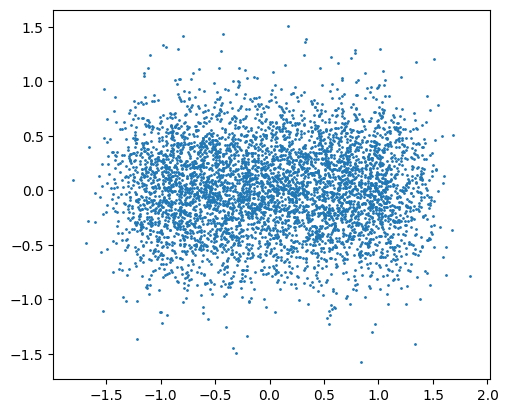

In [191]:
dim = 10

pcs = []
labels = []
for n_gaussians in [2, 3, 4, 5]:
    locs = torch.zeros(n_gaussians, dim)
    locs[:, 0] = torch.linspace(-1, 1, steps=n_gaussians)
    for t in torch.linspace(0.5, 1.5, 20):
        for scale in torch.linspace(0.1, 2.0, 20):
            covar_matrix = scale * torch.diag(torch.linspace(0.1, 1, dim) ** t).expand(n_gaussians, -1, -1)
            gmm = dist.mixture_same_family.MixtureSameFamily(
                mixture_distribution=dist.Categorical(probs=torch.ones(n_gaussians)),
                component_distribution=dist.Independent(
                    dist.MultivariateNormal(locs, covariance_matrix=covar_matrix), 0
                ),
            )

            points = gmm.sample((5000, ))
            labels.append(torch.tensor([n_gaussians, t, scale]))
            pcs.append(points)

torch.save(torch.stack(pcs), "../data/synthetic_gmm/point_clouds.pt")
torch.save(torch.stack(labels), "../data/synthetic_gmm/labels.pt")

fig, ax = plt.subplots()
ax.scatter(*points.T[:2], s=1)
ax.set_aspect("equal")

In [176]:
covar_matrix.shape

torch.Size([3, 2, 2])

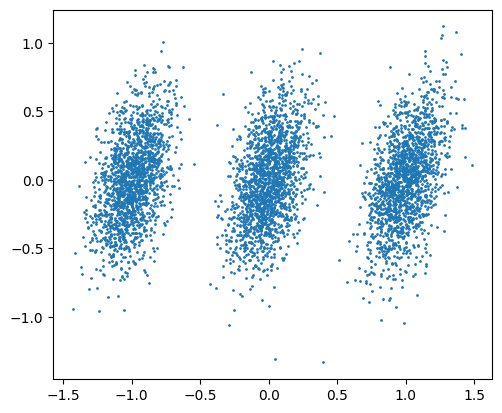

In [188]:
dim = 2
n_gaussians = 3
t = 0.2
scale = 0.1
top_row_scale = 0.2

locs = torch.zeros(n_gaussians, dim)
locs[:, 0] = torch.linspace(-1, 1, steps=n_gaussians)
top_row = torch.ones(dim) * top_row_scale
covar_matrix = torch.diag(torch.linspace(0.1, 1, dim) ** t)
covar_matrix[0] = top_row
covar_matrix[:, 0] = top_row
covar_matrix = scale * covar_matrix.expand(n_gaussians, -1, -1)
gmm = dist.mixture_same_family.MixtureSameFamily(
    mixture_distribution=dist.Categorical(probs=torch.ones(n_gaussians)),
    component_distribution=dist.Independent(
        dist.MultivariateNormal(locs, covariance_matrix=covar_matrix), 0
    ),
)
points = gmm.sample((5000, ))
fig, ax = plt.subplots()
ax.scatter(*points.T[:2], s=1)
ax.set_aspect("equal")

In [86]:
points.T[:2].shape

torch.Size([2, 1000])